<a href="https://colab.research.google.com/github/shanikagalaudage/includeher_paper/blob/main/PlotsTables.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notes
Note this notebook was originally created for the IncludeHer paper, Invisible women: Gender representation in high school science courses across Australia, Ross et al., 2023 (kathryn.ross@curtin.edu.au) which can be found here: https://journals.sagepub.com/doi/full/10.1177/00049441231197245

The notebook has now been modified by Greg Cooke (gjc53@cam.ac.uk) to investigate similar statistics for UK syllabi for 14-16 year olds (GCSE) and 16-18 year olds (A-Level)

# UK A-Level Analysis

In [92]:
# Imports
import numpy as np
import json

from matplotlib import rcParams
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt

# Set plot formatting
rcParams["legend.framealpha"]=0.5
rcParams["legend.frameon"]=True
rcParams["legend.edgecolor"]="white"
rcParams["axes.labelsize"]=14
rcParams["axes.grid"] = True
rcParams["grid.color"] = "black"
rcParams["grid.linewidth"] = 1.0
rcParams["grid.linestyle"] = "--"
rcParams["grid.alpha"] = 0.2

rcParams["xtick.labelsize"]=20
rcParams["ytick.labelsize"]=20
rcParams["legend.fontsize"]=22
rcParams["axes.labelsize"]=22
rcParams["axes.titlesize"]=22

colours = ["#3E284F", "#AB7AD1", "#024963", "#3D9CB3","#C7639D", "#FAA7CB", "#FFEDF7", "#663351"]

# Create JSON files

In [93]:
import json

# Set label lists and dictionary key maps
labels = ["physics", "chemistry", "biology"]
exam_boards = ["AQA", "CCEA", "Edexcel", "OCR", "Scottish_highers", "WJEC"]

SUBJECTS = {
    "physics": "physics",
    "chemistry": "chemistry",
    "biology": "biology",
}

EXAMBOARDS = {
    "AQA": "AQA",
    "CCEA": "CCEA",
    "Edexcel": "Edexcel",
    "OCR": "OCR",
    "Scottish_highers": "Scottish_highers",
    "WJEC": "WJEC",
}

# Read in the new JSON files with "unique" included
dataset = {}
for board in exam_boards:
    path = f"../Stats/{EXAMBOARDS[board]}_SummaryStats_A_Level.json"
    with open(path, "r", encoding="utf-8") as ff:
        dataset[EXAMBOARDS[board]] = json.load(ff)



In [94]:
import json

# Create a json data file with all statistics

subjects = ["biology", "chemistry", "physics"]
exam_boards = ["AQA", "CCEA", "Edexcel", "OCR", "Scottish_highers", "WJEC"]
categories = ["concept", "scientist"]

stats_data = {}
for sb in subjects:
    stats_data[sb] = {}
    for cat in categories:
        stats_data[sb][cat] = {}
        for eb in exam_boards:
            m = dataset[EXAMBOARDS[eb]]["subjects"][SUBJECTS[sb]][cat]["male"]
            f = dataset[EXAMBOARDS[eb]]["subjects"][SUBJECTS[sb]][cat]["female"]
            stats_data[sb][cat][eb] = {"male": m, "female": f, "both": m + f}

# ---- OVERALL SECTION ----

stats_data["overall"] = {}
stats_data["overall"]["exam_boards"] = {}
stats_data["overall"]["subjects"] = {}

tot_across_boards_categories_subjects = 0
tot_across_boards_concept_subjects = 0
tot_across_boards_scientist_subjects = 0

# Overall by subject
for sb in subjects:
    stats_data["overall"]["subjects"][sb] = {}
    tot_across_boards_categories = 0
    for cat in categories:
        tot_across_boards = 0
        for eb in exam_boards:
            tot_across_boards += stats_data[sb][cat][eb]["both"]
        stats_data["overall"]["subjects"][sb][cat] = tot_across_boards
        tot_across_boards_categories += tot_across_boards
    stats_data["overall"]["subjects"][sb]["total"] = tot_across_boards_categories

    tot_across_boards_concept_subjects += stats_data["overall"]["subjects"][sb]["concept"]
    tot_across_boards_scientist_subjects += stats_data["overall"]["subjects"][sb]["scientist"]
    tot_across_boards_categories_subjects += tot_across_boards_categories

for sb in subjects:
    stats_data["overall"]["subjects"][sb]["% of total mentions"] = round(
        stats_data["overall"]["subjects"][sb]["total"] / tot_across_boards_categories_subjects * 100, 2
    )
    stats_data["overall"]["subjects"][sb]["% of total concept mentions"] = round(
        stats_data["overall"]["subjects"][sb]["concept"] / tot_across_boards_concept_subjects * 100, 2
    )
    stats_data["overall"]["subjects"][sb]["% of total scientist mentions"] = round(
        stats_data["overall"]["subjects"][sb]["scientist"] / tot_across_boards_scientist_subjects * 100, 2
    )

# Overall by exam board
tot_across_subjects_categories_boards = 0
tot_across_subjects_concept_boards = 0
tot_across_subjects_scientist_boards = 0

for eb in exam_boards:
    stats_data["overall"]["exam_boards"][eb] = {}
    tot_across_subjects_categories = 0
    for cat in categories:
        tot_across_subjects = 0
        for sb in subjects:
            tot_across_subjects += stats_data[sb][cat][eb]["both"]
        stats_data["overall"]["exam_boards"][eb][cat] = tot_across_subjects
        tot_across_subjects_categories += tot_across_subjects
    stats_data["overall"]["exam_boards"][eb]["total"] = tot_across_subjects_categories

    tot_across_subjects_concept_boards += stats_data["overall"]["exam_boards"][eb]["concept"]
    tot_across_subjects_scientist_boards += stats_data["overall"]["exam_boards"][eb]["scientist"]
    tot_across_subjects_categories_boards += tot_across_subjects_categories

for eb in exam_boards:
    stats_data["overall"]["exam_boards"][eb]["% of total mentions"] = round(
        stats_data["overall"]["exam_boards"][eb]["total"] / tot_across_subjects_categories_boards * 100, 2
    )
    stats_data["overall"]["exam_boards"][eb]["% of total concept mentions"] = round(
        stats_data["overall"]["exam_boards"][eb]["concept"] / tot_across_subjects_concept_boards * 100, 2
    )
    stats_data["overall"]["exam_boards"][eb]["% of total scientist mentions"] = round(
        stats_data["overall"]["exam_boards"][eb]["scientist"] / tot_across_subjects_scientist_boards * 100, 2
    )

# Top-level totals

stats_data["overall"]["total mentions"] = tot_across_boards_categories_subjects
stats_data["overall"]["total concept mentions"] = tot_across_boards_concept_subjects
stats_data["overall"]["total scientist mentions"] = tot_across_boards_scientist_subjects

# Write out
with open('../Stats/FullSummaryStatsUK_A_Level.json', 'w') as fp:
    json.dump(stats_data, fp, indent=4)

#stats_data  # summary statistics

# UK Education Figures

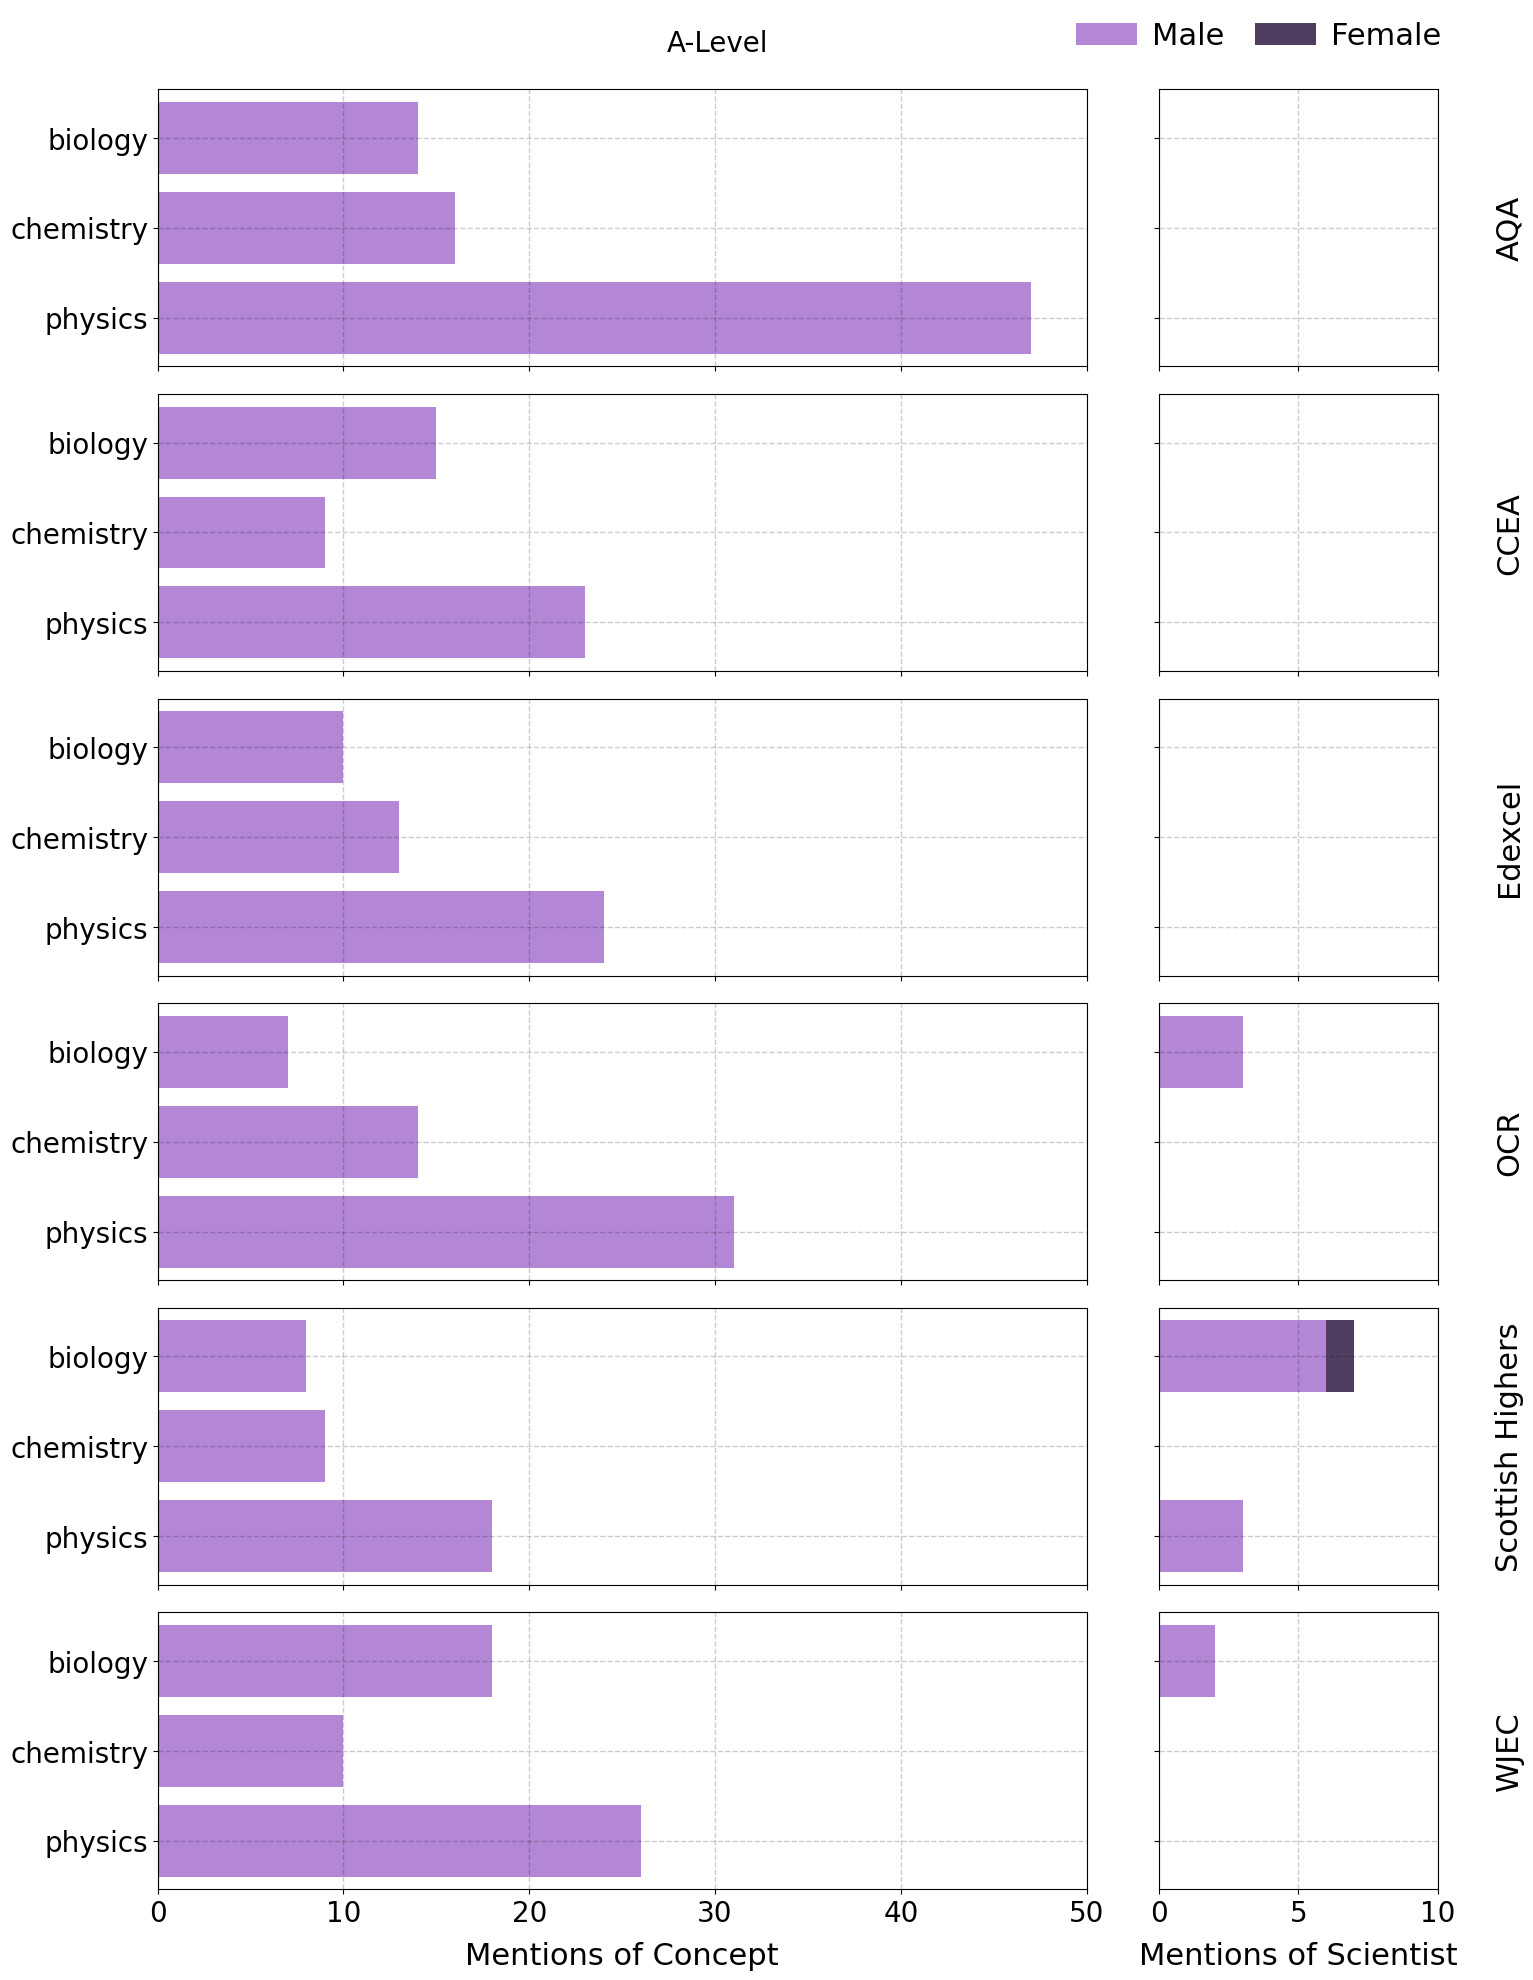

In [95]:
# Create horizontal bar chart for breakdown across subjects (figure 1)
ratio = 4./11.
xmax = 110

fig, axs = plt.subplots(nrows=6, ncols=2, figsize=(16, 20), gridspec_kw={'width_ratios': [1, 0.3]})


ii = 0
for sl in exam_boards:
    male = []
    female = []
    for ll in labels:
        male.append(dataset[EXAMBOARDS[sl]]["subjects"][SUBJECTS[ll]]["concept"]["male"])
        female.append(dataset[EXAMBOARDS[sl]]["subjects"][SUBJECTS[ll]]["concept"]["female"])
    axs[ii, 0].barh(labels, male, color=colours[1], alpha=0.9)
    axs[ii, 0].barh(labels, female, left=male, color=colours[0], alpha=0.9)

    # Set y-label
    if sl == 'Scottish_highers':
        axs[ii, 0].set_ylabel('Scottish Highers', labelpad=-1090)
    else:
        axs[ii, 0].set_ylabel(sl, labelpad=-1090)

    # Set x-limits
    axs[ii, 0].set_xlim(0, 50)

    # Hide x-tick labels if not the bottom row
    if ii != len(exam_boards) - 1:
        axs[ii, 0].tick_params(labelbottom=False)
    ii += 1

# Right-hand scientist column
for ii, sl in enumerate(exam_boards):
    male = []
    female = []
    for ll in labels:
        male.append(dataset[EXAMBOARDS[sl]]["subjects"][SUBJECTS[ll]]["scientist"]["male"])
        female.append(dataset[EXAMBOARDS[sl]]["subjects"][SUBJECTS[ll]]["scientist"]["female"])
    axs[ii, 1].barh(labels, male, color=colours[1], alpha=0.9)
    axs[ii, 1].barh(labels, female, left=male, color=colours[0], alpha=0.9)
    axs[ii, 1].set_xlim(0, 10)

    # Hide y-tick labels on right column
    axs[ii, 1].tick_params(labelleft=False)

    # Hide x-tick labels if not the bottom row
    if ii != len(exam_boards) - 1:
        axs[ii, 1].tick_params(labelbottom=False)


axs[5, 0].set_xlabel("Mentions of Concept",labelpad=10)
axs[5, 1].set_xlabel("Mentions of Scientist",labelpad=10)
plt.figlegend(['Male', 'Female'], bbox_to_anchor=(0.96, 0.99),
          bbox_transform=fig.transFigure, ncol=2, borderaxespad=0., handletextpad=0.5, columnspacing=1)
plt.subplots_adjust(wspace=0.12, hspace=0.1, left=0.15, right=0.95, top=0.95, bottom=0.05)

plt.suptitle('A-Level', fontsize = 20)


plt.savefig('../Figures/summary_subjects_A_Level_UK.png', dpi = 100, bbox_inches='tight')

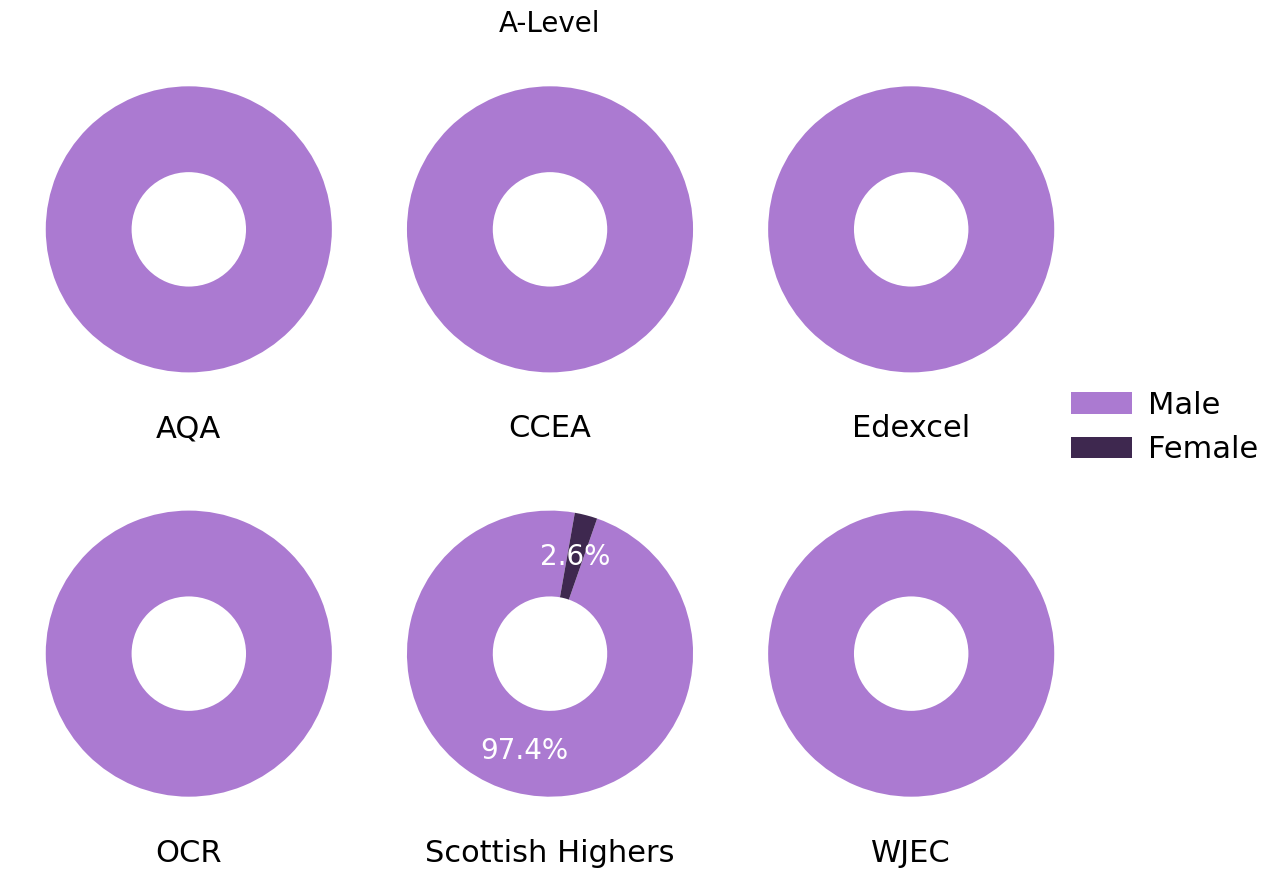

In [96]:
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(12, 9))
ax = ax.flatten()  # flatten to make indexing easier

for jj in range(6):
    m = dataset[EXAMBOARDS[exam_boards[jj]]]["overall"]["unique"]["male"]
    f = dataset[EXAMBOARDS[exam_boards[jj]]]["overall"]["unique"]["female"]
    val = [m, f]
    if f == 0:
        ax[jj].pie(
            val, colors=[colours[1], colours[0]],
            startangle=80, wedgeprops=dict(width=.6),
        )
    else:
        ax[jj].pie(
            val, colors=[colours[1], colours[0]],
            startangle=80, wedgeprops=dict(width=.6),
            autopct='%1.1f%%', pctdistance=0.7,
            textprops={'fontsize': 20, 'color': 'white'}
        )
    
    if (exam_boards[jj] == 'Scottish_highers'):
        ax[jj].set_xlabel('Scottish Highers')
    else:
        ax[jj].set_xlabel(exam_boards[jj])

# Optional: hide any unused axes (e.g. if you ever use fewer than 6)
for kk in range(len(ax)):
    if kk >= len(exam_boards):
        ax[kk].axis('off')
        
plt.figlegend(['Male', 'Female'], bbox_to_anchor=(1.1, 0.57),#(1, 0.55)
              bbox_transform=fig.transFigure, ncol=1, borderaxespad=0.,
              handletextpad=0.5, columnspacing=1)

plt.subplots_adjust(wspace=0.01, hspace=0.1, left=0.05, right=0.95, top=0.95, bottom=0.05)

plt.suptitle('A-Level', fontsize = 20)

plt.savefig('../Figures/summary_male_vs_female_UK_A_Level.png', dpi = 100, bbox_inches='tight')


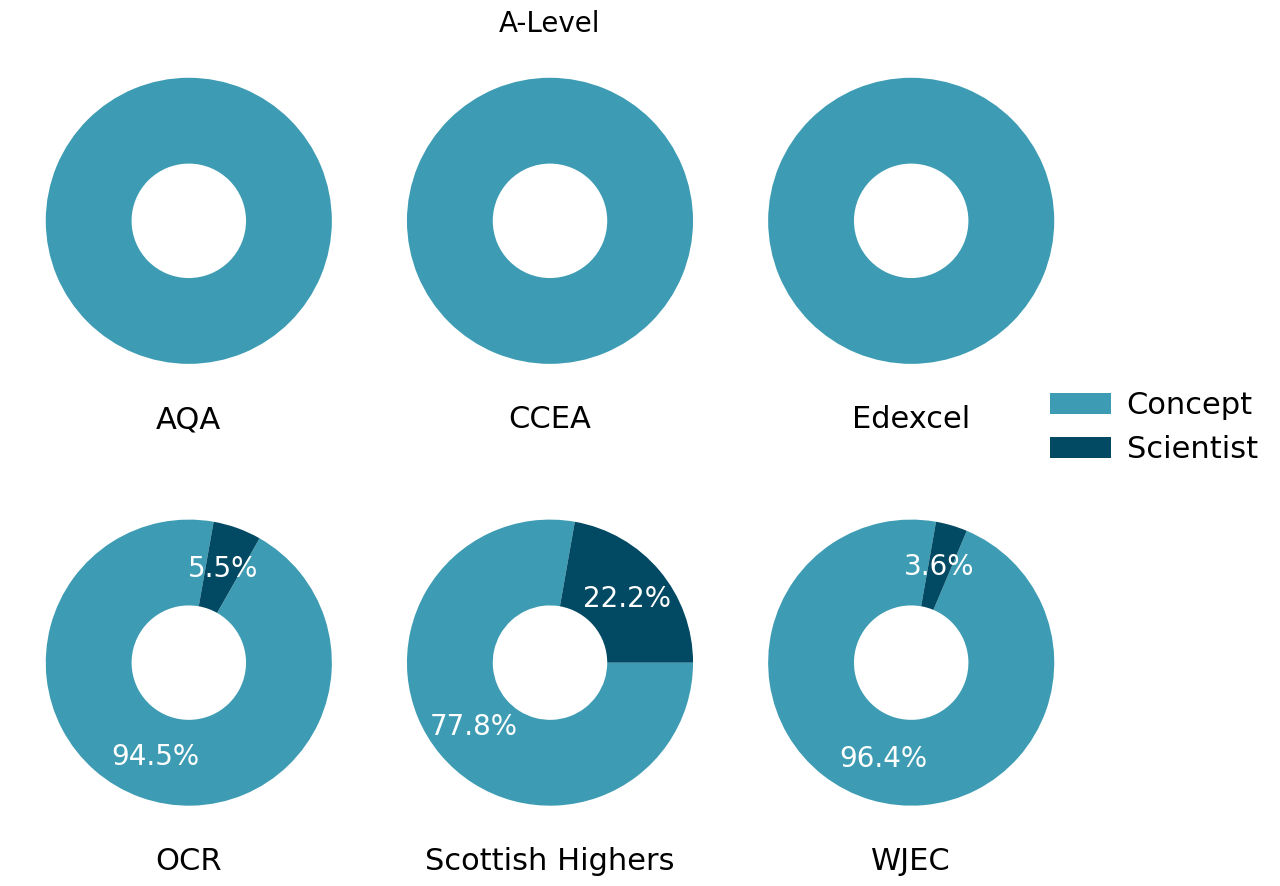

In [97]:
# Create pie charts showing scientist vs concept breakdown per exam board
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(12, 9))
ax = ax.flatten()  # Flatten to simplify iteration

for jj in range(6):  # for each exam board
    board_key = EXAMBOARDS[exam_boards[jj]]
    m1 = dataset[board_key]["overall"]["concept"]["male"]
    f1 = dataset[board_key]["overall"]["concept"]["female"]
    m2 = dataset[board_key]["overall"]["scientist"]["male"]
    f2 = dataset[board_key]["overall"]["scientist"]["female"]

    val = [m1 + f1, m2 + f2]  # [concepts, scientists]

    if m2 + f2 == 0:
        ax[jj].pie(
            val, colors=[colours[3], colours[2]],
            startangle=80, wedgeprops=dict(width=.6)
        )
    else:
        ax[jj].pie(
            val, colors=[colours[3], colours[2]],
            startangle=80, wedgeprops=dict(width=.6),
            autopct='%1.1f%%', pctdistance=0.7,
            textprops={'fontsize': 20, 'color': 'white'}
        )

    if (exam_boards[jj] == 'Scottish_highers'):
        ax[jj].set_xlabel('Scottish Highers')
    else:
        ax[jj].set_xlabel(exam_boards[jj])

# Add legend
plt.figlegend(['Concept', 'Scientist'], bbox_to_anchor=(1.1, 0.57),
              bbox_transform=fig.transFigure, ncol=1,
              borderaxespad=0., handletextpad=0.5, columnspacing=1)

# Adjust spacing
plt.subplots_adjust(wspace=0.01, hspace=0.2, left=0.05, right=0.95, top=0.95, bottom=0.05)

plt.suptitle('A-Level', fontsize = 20)

plt.savefig('../Figures/summary_concept_vs_scientist_UK_A_Level.png', dpi = 100, bbox_inches='tight')


Excluded 'nan' or malformed region entries from 'overall':
  - 'nan'
Excluded 'nan' or malformed region entries from scientists:
  - 'nan'


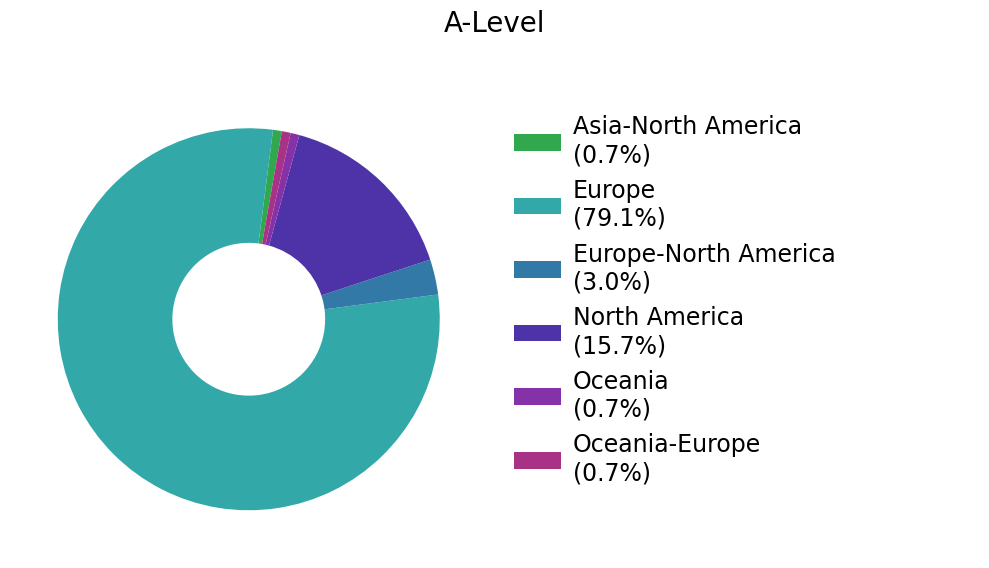

In [98]:
import matplotlib.pyplot as plt
import numpy as np

# --- Collect and clean data ---
region_list = []
nan_regions = set()
for state in exam_boards:
    region_keys = dataset[EXAMBOARDS[state]]["overall"]["unique"]["region"].keys()
    for r in region_keys:
        if isinstance(r, str):
            r_clean = r.strip().title()
            if r_clean == "Eruope":
                r_clean = "Europe"
            if r_clean.lower() == "nan":
                nan_regions.add(r)
            else:
                region_list.append(r_clean)
        else:
            nan_regions.add(r)

# Print nan or malformed entries
if nan_regions:
    print("Excluded 'nan' or malformed region entries from 'overall':")
    for r in nan_regions:
        print(f"  - {repr(r)}")

regions = sorted(set(region_list))

# Assign colors using a qualitative palette
cmap = plt.get_cmap('Set3')

Colours = ["#32a84e", "#32a8a8", "#3279a8",
           "#4e32a8", "#8532a8", "#a83285"]



#colours = [cmap(i % cmap.N) for i in range(len(regions))]

# --- Build list of unique scientist names and regions ---
name_list = []
region = []
nan_regions_scientist = set()
for state in exam_boards:
    names = list(dataset[EXAMBOARDS[state]]["names"].keys())
    for name in names:
        r = dataset[EXAMBOARDS[state]]["names"][name]["region"]
        if isinstance(r, str):
            r_clean = r.strip().title()
            if r_clean == "Eruope":
                r_clean = "Europe"
            if r_clean.lower() == "nan":
                nan_regions_scientist.add(r)
            else:
                region.append(r_clean)
                name_list.append(name)
        else:
            nan_regions_scientist.add(r)

# Print nan or malformed entries
if nan_regions_scientist:
    print("Excluded 'nan' or malformed region entries from scientists:")
    for r in nan_regions_scientist:
        print(f"  - {repr(r)}")

# Remove duplicate scientist names (preserve first mention)
idx = [name_list.index(x) for x in set(name_list)]
unique_names = [name_list[i] for i in idx]
region_names = [region[i] for i in idx]

# Count by region
vals = [region_names.count(rr) for rr in regions]

# Format region names with percentages for the legend
total = sum(vals)
region_labels = [f"{r} ({v/total*100:.1f}%)" for r, v in zip(regions, vals)]

def wrap_label(label, max_words=2):
    words = label.split()
    lines = []
    for i in range(0, len(words), max_words):
        lines.append(" ".join(words[i:i+max_words]))
    return "\n".join(lines)

region_labels = [
    f"{wrap_label(r)}\n({v/total*100:.1f}%)" for r, v in zip(regions, vals)
]


# --- Plotting ---
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 6))

# Main pie chart (no % inside)
ax[0].pie(
    vals, colors=Colours, startangle=80,
    wedgeprops=dict(width=.6), textprops={'fontsize': 18, 'color': 'black'}
)

# Dummy pie chart for layout spacing
ax[1].pie(vals, colors=['white'] * len(vals))

# Legend with region names and percentages
plt.figlegend(
    region_labels,
    bbox_to_anchor=(0.85, 0.82),
    bbox_transform=fig.transFigure,
    ncol=1, borderaxespad=0., handletextpad=0.5, columnspacing=1,
    fontsize=17
)

plt.suptitle('A-Level', fontsize = 20)

plt.tight_layout()

plt.savefig('../Figures/summary_region_all_UK_A_Level.png',
            dpi=100,
            bbox_inches='tight')


# GCSE analysis

#### Code is essentially the same, just with different paths and files

In [99]:
import json

# Set label lists and dictionary key maps
labels = ["physics", "chemistry", "biology"]
exam_boards = ["AQA", "CCEA", "Edexcel", "OCR A", "OCR B", "Scottish NQ5", "WJEC"]

SUBJECTS = {
    "physics": "physics",
    "chemistry": "chemistry",
    "biology": "biology",
}

EXAMBOARDS = {
    "AQA": "AQA_GCSE",
    "CCEA": "CCEA_GCSE",
    "Edexcel": "Edexcel_GCSE",
    "OCR A": "OCR_A_GCSE",
    "OCR B": "OCR_B_GCSE",
    "Scottish NQ5": "Scottish_NQ5",
    "WJEC": "WJEC_GCSE",
}

# Read in the new JSON files with "unique" included
dataset = {}
for board in exam_boards:
    path = f"../Stats/{EXAMBOARDS[board]}_SummaryStats_GCSE.json"
    with open(path, "r", encoding="utf-8") as ff:
        dataset[EXAMBOARDS[board]] = json.load(ff)



FileNotFoundError: [Errno 2] No such file or directory: '../Stats/AQA_SummaryStats_GCSE.json'

In [ ]:
import json

# Create a json data file with all statistics

subjects = ["biology", "chemistry", "physics"]
exam_boards = ["AQA", "CCEA", "Edexcel", "OCR A", "OCR B", "Scottish NQ5", "WJEC"]
categories = ["concept", "scientist"]

stats_data = {}
for sb in subjects:
    stats_data[sb] = {}
    for cat in categories:
        stats_data[sb][cat] = {}
        for eb in exam_boards:
            m = dataset[EXAMBOARDS[eb]]["subjects"][SUBJECTS[sb]][cat]["male"]
            f = dataset[EXAMBOARDS[eb]]["subjects"][SUBJECTS[sb]][cat]["female"]
            stats_data[sb][cat][eb] = {"male": m, "female": f, "both": m + f}

# ---- OVERALL SECTION ----

stats_data["overall"] = {}
stats_data["overall"]["exam_boards"] = {}
stats_data["overall"]["subjects"] = {}

tot_across_boards_categories_subjects = 0
tot_across_boards_concept_subjects = 0
tot_across_boards_scientist_subjects = 0

# Overall by subject
for sb in subjects:
    stats_data["overall"]["subjects"][sb] = {}
    tot_across_boards_categories = 0
    for cat in categories:
        tot_across_boards = 0
        for eb in exam_boards:
            tot_across_boards += stats_data[sb][cat][eb]["both"]
        stats_data["overall"]["subjects"][sb][cat] = tot_across_boards
        tot_across_boards_categories += tot_across_boards
    stats_data["overall"]["subjects"][sb]["total"] = tot_across_boards_categories

    tot_across_boards_concept_subjects += stats_data["overall"]["subjects"][sb]["concept"]
    tot_across_boards_scientist_subjects += stats_data["overall"]["subjects"][sb]["scientist"]
    tot_across_boards_categories_subjects += tot_across_boards_categories

for sb in subjects:
    stats_data["overall"]["subjects"][sb]["% of total mentions"] = round(
        stats_data["overall"]["subjects"][sb]["total"] / tot_across_boards_categories_subjects * 100, 2
    )
    stats_data["overall"]["subjects"][sb]["% of total concept mentions"] = round(
        stats_data["overall"]["subjects"][sb]["concept"] / tot_across_boards_concept_subjects * 100, 2
    )
    stats_data["overall"]["subjects"][sb]["% of total scientist mentions"] = round(
        stats_data["overall"]["subjects"][sb]["scientist"] / tot_across_boards_scientist_subjects * 100, 2
    )

# Overall by exam board
tot_across_subjects_categories_boards = 0
tot_across_subjects_concept_boards = 0
tot_across_subjects_scientist_boards = 0

for eb in exam_boards:
    stats_data["overall"]["exam_boards"][eb] = {}
    tot_across_subjects_categories = 0
    for cat in categories:
        tot_across_subjects = 0
        for sb in subjects:
            tot_across_subjects += stats_data[sb][cat][eb]["both"]
        stats_data["overall"]["exam_boards"][eb][cat] = tot_across_subjects
        tot_across_subjects_categories += tot_across_subjects
    stats_data["overall"]["exam_boards"][eb]["total"] = tot_across_subjects_categories

    tot_across_subjects_concept_boards += stats_data["overall"]["exam_boards"][eb]["concept"]
    tot_across_subjects_scientist_boards += stats_data["overall"]["exam_boards"][eb]["scientist"]
    tot_across_subjects_categories_boards += tot_across_subjects_categories

for eb in exam_boards:
    stats_data["overall"]["exam_boards"][eb]["% of total mentions"] = round(
        stats_data["overall"]["exam_boards"][eb]["total"] / tot_across_subjects_categories_boards * 100, 2
    )
    stats_data["overall"]["exam_boards"][eb]["% of total concept mentions"] = round(
        stats_data["overall"]["exam_boards"][eb]["concept"] / tot_across_subjects_concept_boards * 100, 2
    )
    stats_data["overall"]["exam_boards"][eb]["% of total scientist mentions"] = round(
        stats_data["overall"]["exam_boards"][eb]["scientist"] / tot_across_subjects_scientist_boards * 100, 2
    )

# Top-level totals

stats_data["overall"]["total mentions"] = tot_across_boards_categories_subjects
stats_data["overall"]["total concept mentions"] = tot_across_boards_concept_subjects
stats_data["overall"]["total scientist mentions"] = tot_across_boards_scientist_subjects

# Write out
with open('../Stats/FullSummaryStatsUK_GCSE.json', 'w') as fp:
    json.dump(stats_data, fp, indent=4)

#stats_data  # summary statistics

# Figures 

### Subjects

KeyError: 'AQA'

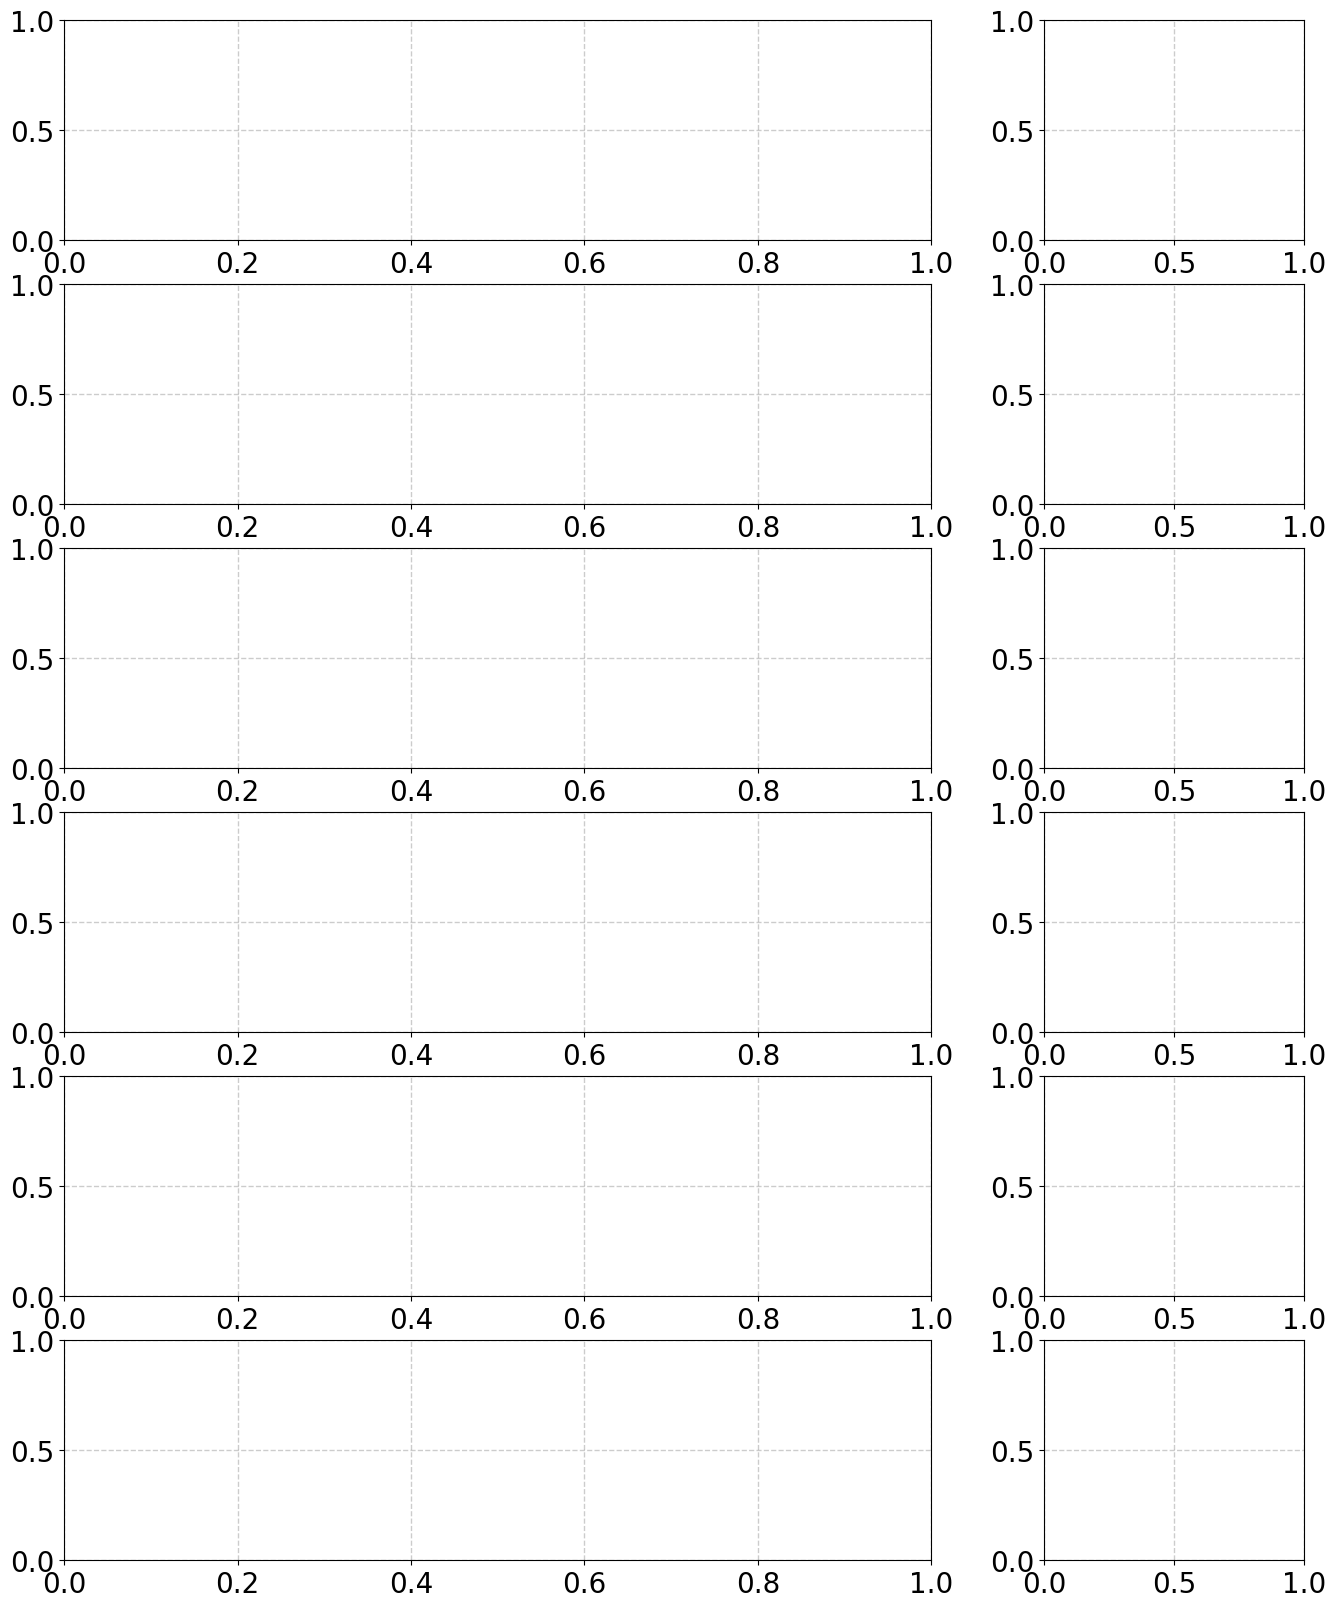

In [100]:
# Create horizontal bar chart for breakdown across subjects (figure 1)
ratio = 4./11.
xmax = 110

fig, axs = plt.subplots(nrows=6, ncols=2, figsize=(16, 20), gridspec_kw={'width_ratios': [1, 0.3]})


ii = 0
for sl in exam_boards:
    male = []
    female = []
    for ll in labels:
        male.append(dataset[EXAMBOARDS[sl]]["subjects"][SUBJECTS[ll]]["concept"]["male"])
        female.append(dataset[EXAMBOARDS[sl]]["subjects"][SUBJECTS[ll]]["concept"]["female"])
    axs[ii, 0].barh(labels, male, color=colours[1], alpha=0.9)
    axs[ii, 0].barh(labels, female, left=male, color=colours[0], alpha=0.9)

    # Set y-label
    if sl == 'Scottish_highers':
        axs[ii, 0].set_ylabel('Scottish Highers', labelpad=-1090)
    else:
        axs[ii, 0].set_ylabel(sl, labelpad=-1090)

    # Set x-limits
    axs[ii, 0].set_xlim(0, 50)

    # Hide x-tick labels if not the bottom row
    if ii != len(exam_boards) - 1:
        axs[ii, 0].tick_params(labelbottom=False)
    ii += 1

# Right-hand scientist column
for ii, sl in enumerate(exam_boards):
    male = []
    female = []
    for ll in labels:
        male.append(dataset[EXAMBOARDS[sl]]["subjects"][SUBJECTS[ll]]["scientist"]["male"])
        female.append(dataset[EXAMBOARDS[sl]]["subjects"][SUBJECTS[ll]]["scientist"]["female"])
    axs[ii, 1].barh(labels, male, color=colours[1], alpha=0.9)
    axs[ii, 1].barh(labels, female, left=male, color=colours[0], alpha=0.9)
    axs[ii, 1].set_xlim(0, 10)

    # Hide y-tick labels on right column
    axs[ii, 1].tick_params(labelleft=False)

    # Hide x-tick labels if not the bottom row
    if ii != len(exam_boards) - 1:
        axs[ii, 1].tick_params(labelbottom=False)


axs[5, 0].set_xlabel("Mentions of Concept",labelpad=10)
axs[5, 1].set_xlabel("Mentions of Scientist",labelpad=10)
plt.figlegend(['Male', 'Female'], bbox_to_anchor=(0.96, 0.99),
          bbox_transform=fig.transFigure, ncol=2, borderaxespad=0., handletextpad=0.5, columnspacing=1)
plt.subplots_adjust(wspace=0.12, hspace=0.1, left=0.15, right=0.95, top=0.95, bottom=0.05)

plt.suptitle('GCSE', fontsize = 20)


plt.savefig('../Figures/summary_subjects_GCSE_UK.png', dpi = 100, bbox_inches='tight')

### Male compared to female mentions

In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(12, 9))
ax = ax.flatten()  # flatten to make indexing easier

for jj in range(6):
    m = dataset[EXAMBOARDS[exam_boards[jj]]]["overall"]["unique"]["male"]
    f = dataset[EXAMBOARDS[exam_boards[jj]]]["overall"]["unique"]["female"]
    val = [m, f]
    if f == 0:
        ax[jj].pie(
            val, colors=[colours[1], colours[0]],
            startangle=80, wedgeprops=dict(width=.6),
        )
    else:
        ax[jj].pie(
            val, colors=[colours[1], colours[0]],
            startangle=80, wedgeprops=dict(width=.6),
            autopct='%1.1f%%', pctdistance=0.7,
            textprops={'fontsize': 20, 'color': 'white'}
        )
    
    if (exam_boards[jj] == 'Scottish_highers'):
        ax[jj].set_xlabel('Scottish Highers')
    else:
        ax[jj].set_xlabel(exam_boards[jj])

# Optional: hide any unused axes (e.g. if you ever use fewer than 6)
for kk in range(len(ax)):
    if kk >= len(exam_boards):
        ax[kk].axis('off')
        
plt.figlegend(['Male', 'Female'], bbox_to_anchor=(1.1, 0.57),#(1, 0.55)
              bbox_transform=fig.transFigure, ncol=1, borderaxespad=0.,
              handletextpad=0.5, columnspacing=1)

plt.subplots_adjust(wspace=0.01, hspace=0.1, left=0.05, right=0.95, top=0.95, bottom=0.05)

plt.suptitle('GCSE', fontsize = 20)

plt.savefig('../Figures/summary_male_vs_female_UK_GCSE.png', dpi = 100, bbox_inches='tight')


### Exam boards

KeyError: 'AQA'

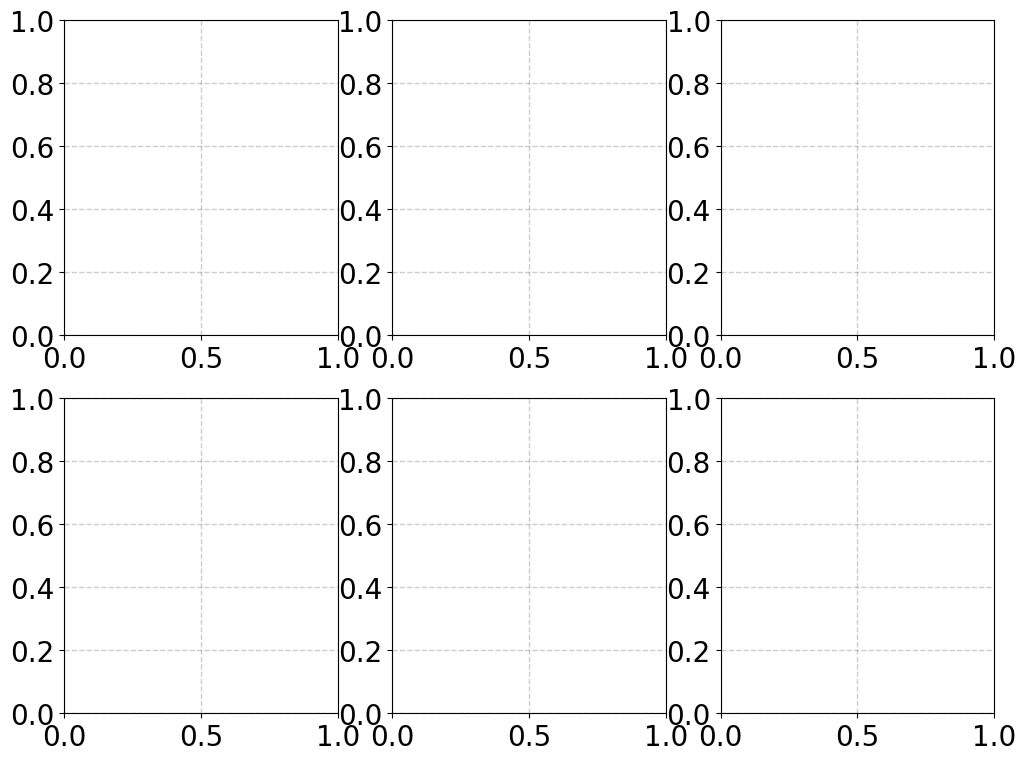

In [101]:
# Create pie charts showing scientist vs concept breakdown per exam board
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(12, 9))
ax = ax.flatten()  # Flatten to simplify iteration

for jj in range(6):  # for each exam board
    board_key = EXAMBOARDS[exam_boards[jj]]
    m1 = dataset[board_key]["overall"]["concept"]["male"]
    f1 = dataset[board_key]["overall"]["concept"]["female"]
    m2 = dataset[board_key]["overall"]["scientist"]["male"]
    f2 = dataset[board_key]["overall"]["scientist"]["female"]

    val = [m1 + f1, m2 + f2]  # [concepts, scientists]

    if m2 + f2 == 0:
        ax[jj].pie(
            val, colors=[colours[3], colours[2]],
            startangle=80, wedgeprops=dict(width=.6)
        )
    else:
        ax[jj].pie(
            val, colors=[colours[3], colours[2]],
            startangle=80, wedgeprops=dict(width=.6),
            autopct='%1.1f%%', pctdistance=0.7,
            textprops={'fontsize': 20, 'color': 'white'}
        )

    if (exam_boards[jj] == 'Scottish_highers'):
        ax[jj].set_xlabel('Scottish Highers')
    else:
        ax[jj].set_xlabel(exam_boards[jj])

# Add legend
plt.figlegend(['Concept', 'Scientist'], bbox_to_anchor=(1.1, 0.57),
              bbox_transform=fig.transFigure, ncol=1,
              borderaxespad=0., handletextpad=0.5, columnspacing=1)

# Adjust spacing
plt.subplots_adjust(wspace=0.01, hspace=0.2, left=0.05, right=0.95, top=0.95, bottom=0.05)

plt.suptitle('GCSE', fontsize = 20)

plt.savefig('../Figures/summary_concept_vs_scientist_UK_GCSE.png', dpi = 100, bbox_inches='tight')


### Regions of the world

In [102]:
import matplotlib.pyplot as plt
import numpy as np

# --- Collect and clean data ---
region_list = []
nan_regions = set()
for state in exam_boards:
    region_keys = dataset[EXAMBOARDS[state]]["overall"]["unique"]["region"].keys()
    for r in region_keys:
        if isinstance(r, str):
            r_clean = r.strip().title()
            if r_clean == "Eruope":
                r_clean = "Europe"
            if r_clean.lower() == "nan":
                nan_regions.add(r)
            else:
                region_list.append(r_clean)
        else:
            nan_regions.add(r)

# Print nan or malformed entries
if nan_regions:
    print("Excluded 'nan' or malformed region entries from 'overall':")
    for r in nan_regions:
        print(f"  - {repr(r)}")

regions = sorted(set(region_list))

# Assign colors using a qualitative palette
cmap = plt.get_cmap('Set3')

Colours = ["#32a84e", "#32a8a8", "#3279a8",
           "#4e32a8", "#8532a8", "#a83285"]



#colours = [cmap(i % cmap.N) for i in range(len(regions))]

# --- Build list of unique scientist names and regions ---
name_list = []
region = []
nan_regions_scientist = set()
for state in exam_boards:
    names = list(dataset[EXAMBOARDS[state]]["names"].keys())
    for name in names:
        r = dataset[EXAMBOARDS[state]]["names"][name]["region"]
        if isinstance(r, str):
            r_clean = r.strip().title()
            if r_clean == "Eruope":
                r_clean = "Europe"
            if r_clean.lower() == "nan":
                nan_regions_scientist.add(r)
            else:
                region.append(r_clean)
                name_list.append(name)
        else:
            nan_regions_scientist.add(r)

# Print nan or malformed entries
if nan_regions_scientist:
    print("Excluded 'nan' or malformed region entries from scientists:")
    for r in nan_regions_scientist:
        print(f"  - {repr(r)}")

# Remove duplicate scientist names (preserve first mention)
idx = [name_list.index(x) for x in set(name_list)]
unique_names = [name_list[i] for i in idx]
region_names = [region[i] for i in idx]

# Count by region
vals = [region_names.count(rr) for rr in regions]

# Format region names with percentages for the legend
total = sum(vals)
region_labels = [f"{r} ({v/total*100:.1f}%)" for r, v in zip(regions, vals)]

def wrap_label(label, max_words=2):
    words = label.split()
    lines = []
    for i in range(0, len(words), max_words):
        lines.append(" ".join(words[i:i+max_words]))
    return "\n".join(lines)

region_labels = [
    f"{wrap_label(r)}\n({v/total*100:.1f}%)" for r, v in zip(regions, vals)
]


# --- Plotting ---
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 6))

# Main pie chart (no % inside)
ax[0].pie(
    vals, colors=Colours, startangle=80,
    wedgeprops=dict(width=.6), textprops={'fontsize': 18, 'color': 'black'}
)

# Dummy pie chart for layout spacing
ax[1].pie(vals, colors=['white'] * len(vals))

# Legend with region names and percentages
plt.figlegend(
    region_labels,
    bbox_to_anchor=(0.85, 0.82),
    bbox_transform=fig.transFigure,
    ncol=1, borderaxespad=0., handletextpad=0.5, columnspacing=1,
    fontsize=17
)

plt.suptitle('GCSE', fontsize = 20)

plt.tight_layout()

plt.savefig('../Figures/summary_region_all_GCSE.png',
            dpi=100,
            bbox_inches='tight')


KeyError: 'AQA'